# Customer Retention & Churn Analysis  

### Data Science & Analytics Internship – Future Interns  

**Author:** Kumar Ansh Prasad  
**Track Code:** DS  
**Task:** FUTURE_DS_02  

---

##  Project Overview  

This project analyzes customer retention and churn behavior for a subscription-based business.  
The objective is to identify churn patterns, high-risk customer segments, and actionable strategies to improve retention and customer lifetime value.

---

##  Key Objectives  

- Calculate overall churn rate  
- Identify high-risk customer segments  
- Analyze retention trends by contract type and tenure  
- Evaluate pricing and payment behavior impact  
- Provide business recommendations to reduce churn  

---

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

 4. Overall Churn Rate
Calculating percentage of customers who left the company.

In [8]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

**Insight:** Approximately 26% customers have churned, indicating moderate retention risk.

## 5. Churn Analysis by Contract Type
Analyzing which contract type has the highest churn rate.

In [9]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## 6. Customer Tenure Analysis
Comparing average tenure of churned vs retained customers.

In [10]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

## 7. Monthly Charges vs Churn
Analyzing whether higher monthly charges are associated with higher churn.

In [11]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

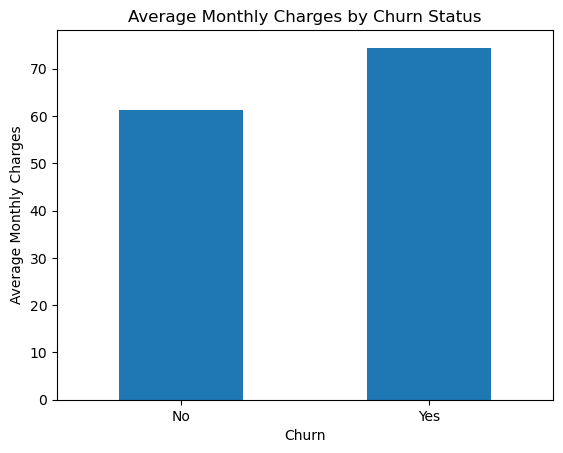

In [13]:
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()

avg_charges.plot(kind='bar')

plt.title("Average Monthly Charges by Churn Status")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

**Insight:** Customers who churn pay significantly higher monthly charges on average, indicating possible price sensitivity.

## 8. Churn Analysis by Payment Method
Identifying which payment methods are associated with higher churn.

In [14]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


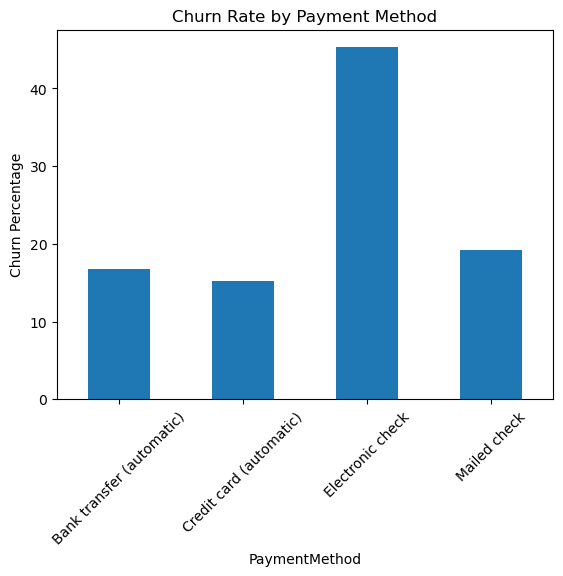

In [15]:
payment_churn['Yes'].plot(kind='bar')

plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=45)
plt.show()

**Insight:** Customers using electronic check show the highest churn rate, suggesting possible payment friction or lower commitment levels.

## 9. High-Risk Customer Segment Analysis
Identifying customers most likely to churn based on contract type and tenure.

In [18]:
df['TenureGroup'] = pd.cut(df['tenure'],
                           bins=[0,6,12,24,60,72],
                           labels=['0-6','6-12','1-2yr','2-5yr','5+yr'])

In [19]:
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
tenure_churn

Churn,No,Yes
TenureGroup,,
0-6,46.666667,53.333333
6-12,64.113475,35.886525
1-2yr,71.289062,28.710938
2-5yr,81.657049,18.342951
5+yr,93.390192,6.609808


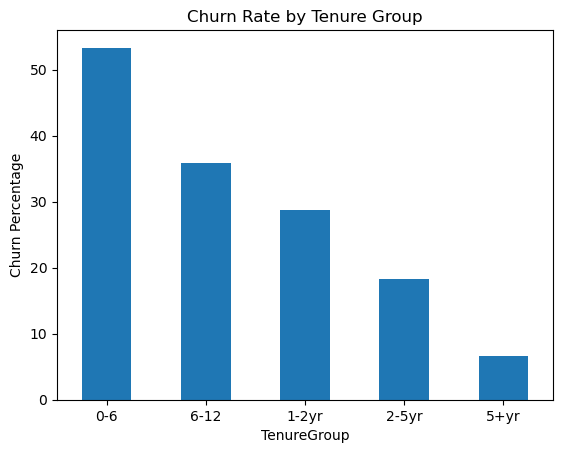

In [20]:
tenure_churn['Yes'].plot(kind='bar')

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)
plt.show()

In [21]:
high_risk = df[(df['Contract']=="Month-to-month") & (df['tenure']<6)]
high_risk['Churn'].value_counts(normalize=True)*100

Churn
Yes    56.145675
No     43.854325
Name: proportion, dtype: float64

**Insight:** Customers with month-to-month contracts and tenure below 6 months show the highest churn risk. Early engagement strategies are critical.

# 10. Executive Summary

### Key Findings:

- Overall churn rate is approximately 26–27%.
- Month-to-month contract customers show the highest churn rate.
- Customers with tenure below 6 months are most likely to churn.
- Customers paying higher monthly charges tend to churn more.
- Electronic check users have higher churn compared to auto-payment users.

These insights indicate that early-stage engagement, pricing sensitivity, and contract structure significantly influence customer retention.

# 11. Business Recommendations

Based on the analysis, the following actions are recommended:

1. Encourage long-term contracts by offering discounts for annual or two-year plans.
2. Improve onboarding experience for customers within the first 6 months.
3. Provide loyalty incentives for high-paying customers.
4. Promote auto-payment methods to reduce churn risk.
5. Identify high-risk segments early and launch targeted retention campaigns.

Implementing these strategies can help reduce churn and improve customer lifetime value.